
# VAE-GAN en microbioma (con y sin Helicobacter pylori)

Este notebook compara el comportamiento del modelo en:
- Dataset completo (con H. pylori)
- Dataset sin H. pylori

Objetivo: evaluar si el modelo depende excesivamente de esa variable dominante.


In [ ]:

!pip install torch torchvision scikit-learn pandas matplotlib seaborn


# Tarea

Realizar un Análisis Exploratorio de Datos (EDA) e implementar un modelo VAE-GAN para analizar datos de microbioma a partir de los siguientes archivos:  
"otu_genus_clr_prevfiltered-hp.csv", "sample_metadata_binary-hp.csv", "otu_genus_clr_prevfiltered-nhp.csv" y "sample_metadata_binary-nhp.csv".  

La tarea incluye:

1. **EDA**: Estadísticas descriptivas y análisis de correlación de los géneros bacterianos.  

2. **Preprocesamiento**: Limpieza de datos (manejo de NaNs/Infs) y normalización, asegurando la alineación entre las tablas OTU y los metadatos.  

3. **Implementación del Modelo**: Construcción y entrenamiento de un VAE-GAN (Codificador, Decodificador, Discriminador) utilizando una función de pérdida combinada (Reconstrucción, Divergencia KL y Adversarial).  

4. **Comparación**: Comparar sistemáticamente el rendimiento del modelo y el comportamiento del entrenamiento entre el conjunto de datos que contiene *H. pylori* y el que no lo contiene.  

5. **Visualización**: Graficar las curvas de pérdida y utilizar técnicas de reducción de dimensionalidad (PCA/t-SNE) para visualizar el espacio latente.  

6. **Interpretación**: Determinar si el modelo captura patrones complejos del microbioma o si está principalmente influenciado por la presencia de *Helicobacter*.  

## Análisis Exploratorio de Datos (EDA)

Realizar un análisis detallado de los archivos CSV cargados (HP y No HP), incluyendo estadísticas descriptivas y correlaciones.

In [ ]:
import seaborn as sns

# 1. Descriptive Statistics
print("--- Estadísticas Descriptivas: Dataset con HP ---")
display(data_hp.describe())

print("\n--- Estadísticas Descriptivas: Dataset sin HP ---")
display(data_nhp.describe())

# Check for class balance in metadata
print("\n--- Balance de Clases (label_binary) ---")
print("HP Dataset:", metadata_hp['label_binary'].value_counts(normalize=True).to_dict())
print("No HP Dataset:", metadata_nhp['label_binary'].value_counts(normalize=True).to_dict())

--- Estadísticas Descriptivas: Dataset con HP ---


,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,Capnocytophaga,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,...,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,0.020107,3.882244,-0.126531,3.188654,2.193266,-0.117304,3.310548,2.041995,1.446239,1.025913,...,0.464706,2.090573,5.620832,-0.234131,0.680378,-0.174366,1.102061,5.274909,4.452215,3.284698
std,1.336942,1.855874,1.190461,1.248273,1.865393,1.068851,1.310213,1.578505,1.780326,1.837319,...,1.299238,1.233034,1.577476,1.150065,1.621677,0.990621,1.899642,1.201093,1.698764,2.025854
min,-1.233749,0.527966,-1.341878,0.642346,-1.238502,-1.512935,0.444744,-1.238502,-1.329606,-1.329606,...,-1.512935,-0.345344,2.724056,-1.512935,-1.329606,-1.512935,-1.329606,3.171569,-0.279920,-1.238502
25%,-0.847989,2.585945,-0.755636,2.355430,0.785841,-0.847989,2.452107,0.841706,-0.279920,-0.469103,...,-0.668738,1.525118,4.315640,-0.859755,-0.570593,-0.859755,-0.415111,4.378089,3.152620,2.452409
50%,-0.467836,3.820098,-0.467836,3.197061,2.785120,-0.373811,3.163370,2.083351,1.332030,0.775457,...,0.473493,1.960747,6.185507,-0.469103,-0.094243,-0.469103,1.168852,4.995335,4.591170,3.784084
75%,0.391389,5.432855,0.072880,3.696612,3.822852,0.224981,4.291771,3.137800,3.017624,2.575938,...,1.384893,2.427708,6.809004,-0.063403,2.080520,0.513173,1.949151,6.275081,5.870402,4.416165
max,4.143998,6.476868,3.435229,6.664077,4.674903,2.943589,6.037687,5.039822,4.178964,4.682144,...,3.483684,5.762720,7.952309,4.045117,4.111490,2.243472,6.138235,7.637268,6.600093,6.108403



--- Estadísticas Descriptivas: Dataset sin HP ---


,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,Capnocytophaga,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,...,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,0.086560,5.207354,-0.198892,4.539637,2.794562,0.060883,4.665655,2.889978,2.044256,1.344409,...,1.175542,3.412470,6.989243,-0.355295,0.914774,0.067650,1.769407,6.645553,5.641693,4.189535
std,1.832293,1.107975,1.558183,1.572904,2.309624,1.646832,1.670716,1.776266,2.107555,2.305114,...,2.113320,1.718254,0.694029,1.425478,2.148625,1.800939,2.311637,0.763454,1.517221,2.335349
min,-1.331660,2.200066,-1.334003,0.768798,-1.216811,-1.658067,0.565253,-1.331660,-1.334003,-1.334003,...,-1.506559,-0.265666,5.391210,-1.658067,-1.658067,-1.658067,-1.334003,5.079657,-0.950673,-1.216811
25%,-1.189803,4.318762,-1.190066,3.484704,1.820975,-1.179833,3.667582,2.932984,-0.903790,-1.098505,...,-0.995831,2.205453,6.437482,-1.190066,-1.141389,-1.179833,-0.903790,6.016757,5.413351,3.866681
50%,-0.950673,5.486188,-0.981607,4.254018,3.902636,-0.903790,4.914239,3.345130,2.650484,2.446264,...,1.054725,3.339698,6.888846,-1.031777,0.608863,-0.981607,2.360099,6.577126,6.080184,4.803846
75%,1.137045,5.957063,0.400804,5.651267,4.485090,1.498868,5.848377,3.758715,3.746122,3.453692,...,2.767018,4.851773,7.426230,0.140554,2.659767,1.069354,3.463585,7.161675,6.434845,5.909736
max,4.446766,6.687804,4.625595,7.118338,5.304177,3.357395,7.792154,5.547010,4.331405,4.689815,...,5.046262,5.920735,8.219699,4.197448,4.431690,4.197292,6.291336,8.180158,7.009965,6.571182



--- Balance de Clases (label_binary) ---
HP Dataset: {1: 0.6896551724137931, 0: 0.3103448275862069}
No HP Dataset: {1: 0.6896551724137931, 0: 0.3103448275862069}


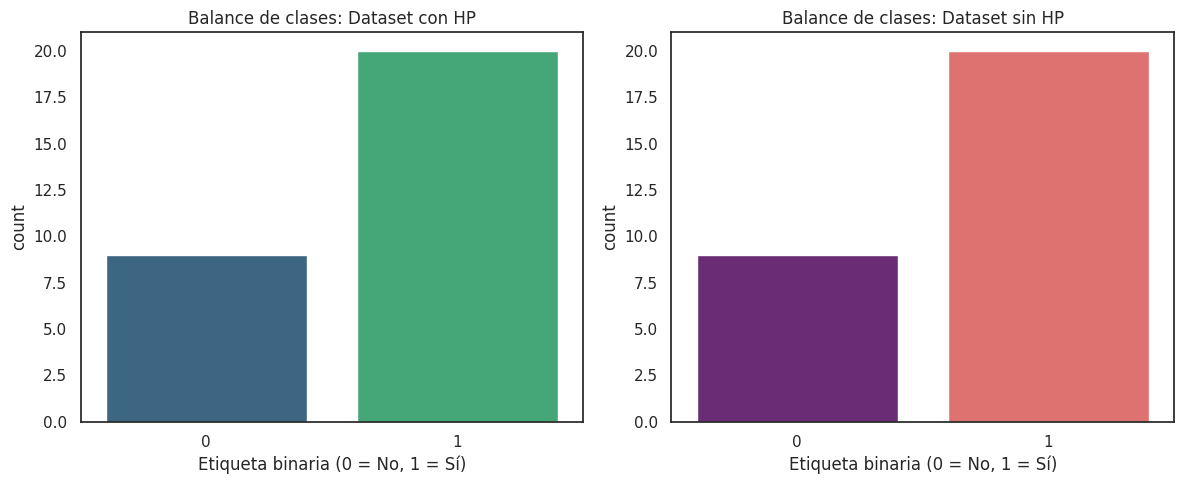

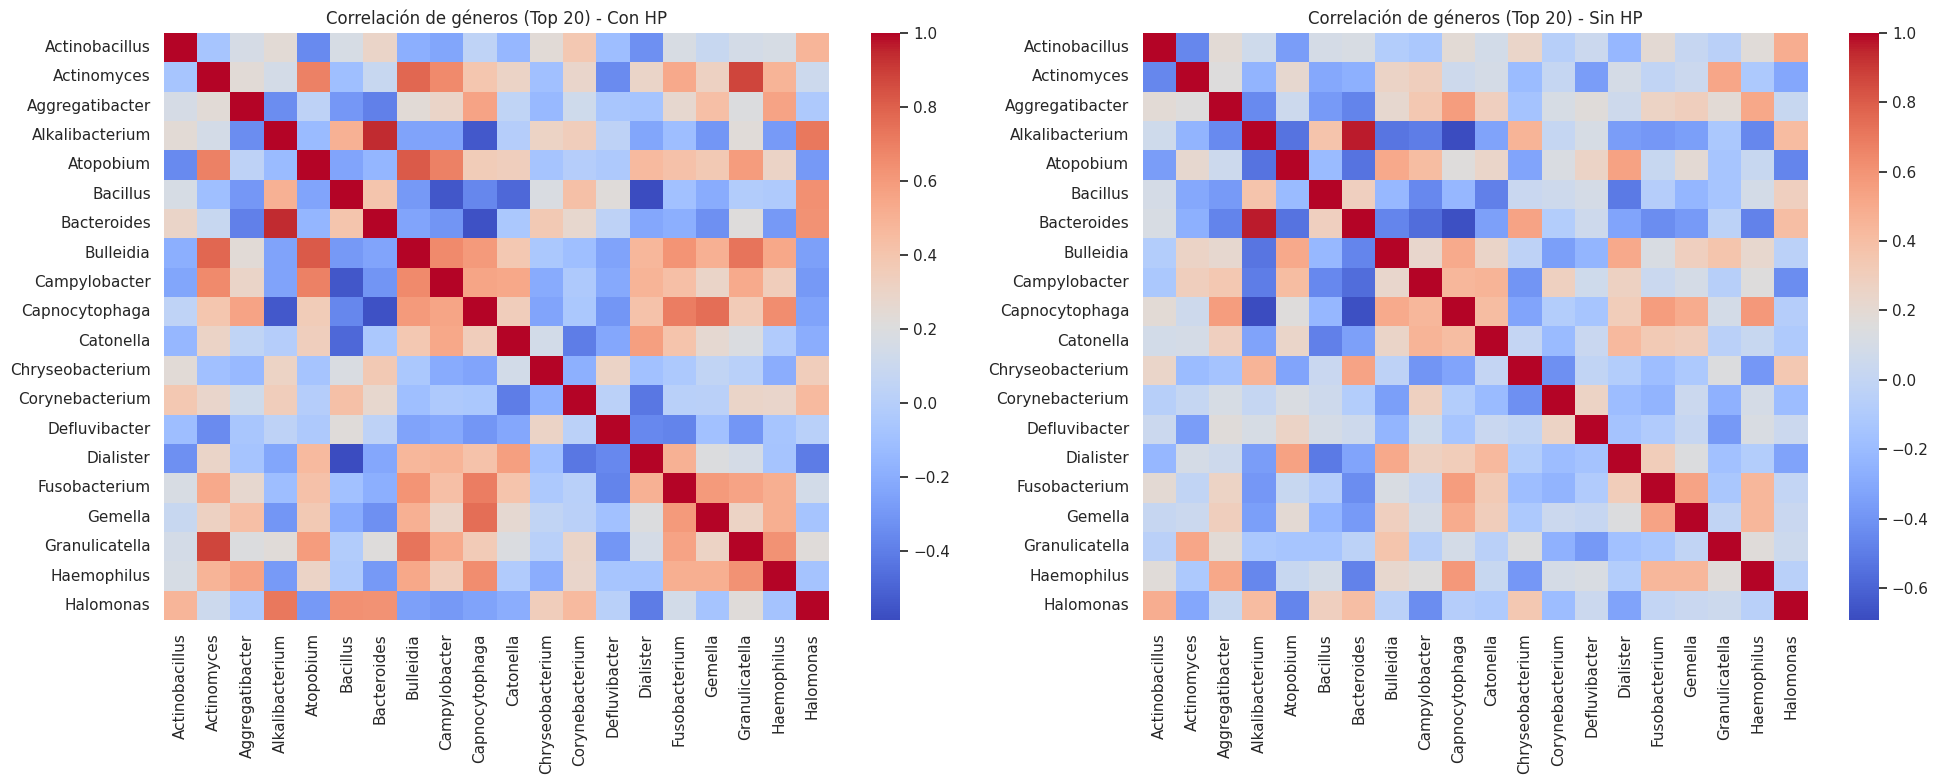

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de las gráficas
sns.set_theme(style="white")

# 1. Visualización del balance de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Balance del dataset con HP
sns.countplot(x='label_binary', data=metadata_hp, ax=axes[0], hue='label_binary', palette='viridis', legend=False)
axes[0].set_title('Balance de clases: Dataset con HP')
axes[0].set_xlabel('Etiqueta binaria (0 = No, 1 = Sí)')

# Balance del dataset sin HP
sns.countplot(x='label_binary', data=metadata_nhp, ax=axes[1], hue='label_binary', palette='magma', legend=False)
axes[1].set_title('Balance de clases: Dataset sin HP')
axes[1].set_xlabel('Etiqueta binaria (0 = No, 1 = Sí)')

plt.tight_layout()
plt.show()

# 2. Análisis de correlación
# Tomamos un subconjunto de los primeros 20 géneros para una mejor visualización en los mapas de calor
corr_hp = data_hp.iloc[:, :20].corr()
corr_nhp = data_nhp.iloc[:, :20].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(corr_hp, annot=False, cmap='coolwarm', ax=ax1)
ax1.set_title('Correlación de géneros (Top 20) - Con HP')

sns.heatmap(corr_nhp, annot=False, cmap='coolwarm', ax=ax2)
ax2.set_title('Correlación de géneros (Top 20) - Sin HP')

plt.tight_layout()
plt.show()

## Preprocesamiento y Limpieza

Consolidar el código de limpieza (manejo de NaNs/Infinitos) y normalización mediante una función robusta para alinear metadatos y OTUs.


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def preprocess_microbiome_data(otu_df, metadata_df, label_col='label_binary'):
    # 1. Alineación por Sample_ID
    common_samples = otu_df.index.intersection(metadata_df.index)
    X = otu_df.loc[common_samples].copy()
    y_series = metadata_df.loc[common_samples, label_col]

    # Eliminar filas con etiquetas faltantes si las hubiera
    mask = y_series.notna()
    X = X[mask]
    y = y_series[mask].values.reshape(-1, 1)

    # 2. Manejo de NaNs e Infinitos
    X_clean = np.nan_to_num(X.values, nan=0.0, posinf=0.0, neginf=0.0)

    # 3. Normalización MinMaxScaler [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_scaled = scaler.fit_transform(X_clean)

    return X_scaled, y

# 4. Ejecución para ambos datasets
X_hp_scaled, y_hp = preprocess_microbiome_data(data_hp, metadata_hp)
X_nhp_scaled, y_nhp = preprocess_microbiome_data(data_nhp, metadata_nhp)

# 5. Verificación de dimensiones
print(f'Dataset con HP - Features: {X_hp_scaled.shape}, Labels: {y_hp.shape}')
print(f'Dataset sin HP - Features: {X_nhp_scaled.shape}, Labels: {y_nhp.shape}')

Dataset con HP - Features: (29, 60), Labels: (29, 1)
Dataset sin HP - Features: (29, 59), Labels: (29, 1)


## Definición de Arquitectura VAE-GAN

Reorganizar y documentar las clases de la red neuronal (Encoder, Decoder, Discriminator) y las funciones de pérdida.


In [ ]:
# =============================================================================
# ARQUITECTURA VAE-GAN
# =============================================================================

class Encoder(nn.Module):
    """
    Encoder: Mapea los datos de entrada al espacio latente.
    Calcula la media (mu) y el logaritmo de la varianza (logvar) para la
    distribución latente de cada muestra.
    """
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    """
    Decoder: Reconstruye los datos originales a partir de un vector latente z.
    Utiliza capas lineales para proyectar el espacio latente de vuelta a la
    dimensión de los géneros bacterianos.
    """
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, 64)
        self.fc_out = nn.Linear(64, output_dim)
        self.relu = nn.ReLU()

    def forward(self, z):
        h = self.relu(self.fc1(z))
        # No usamos Sigmoid al final porque los datos CLR pueden tener valores negativos
        return self.fc_out(h)

class Discriminator(nn.Module):
    """
    Discriminator: Clasificador binario que intenta distinguir entre datos reales
    y datos generados (reconstruidos). En VAE-GAN, ayuda a que el decoder genere
    muestras más realistas mediante entrenamiento adversarial.
    """
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

def reparameterize(mu, logvar):
    """
    Truco de reparametrización: Permite el backpropagation a través de nodos estocásticos.
    z = mu + epsilon * std, donde epsilon ~ N(0, 1).
    """
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

def vae_loss_function(recon_x, x, mu, logvar):
    """
    Función de pérdida VAE:
    1. MSE: Error de reconstrucción (qué tan parecido es el output al input).
    2. KLD: Divergencia de Kullback-Leibler (regulariza el espacio latente hacia N(0,1)).
    """
    mse_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')
    kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return mse_loss + kld_loss

print("Arquitectura VAE-GAN definida y documentada.")

Arquitectura VAE-GAN definida y documentada.


## Entrenamiento Modular y Validación

Refactorizar y ejecutar la función de entrenamiento para comparar sistemáticamente los datasets con y sin H. pylori utilizando validación cruzada.


Iniciando entrenamiento para: Dataset HP
  - Fold 1 completado.
  - Fold 2 completado.
  - Fold 3 completado.
  - Fold 4 completado.
  - Fold 5 completado.
Iniciando entrenamiento para: Dataset No HP
  - Fold 1 completado.
  - Fold 2 completado.
  - Fold 3 completado.
  - Fold 4 completado.
  - Fold 5 completado.


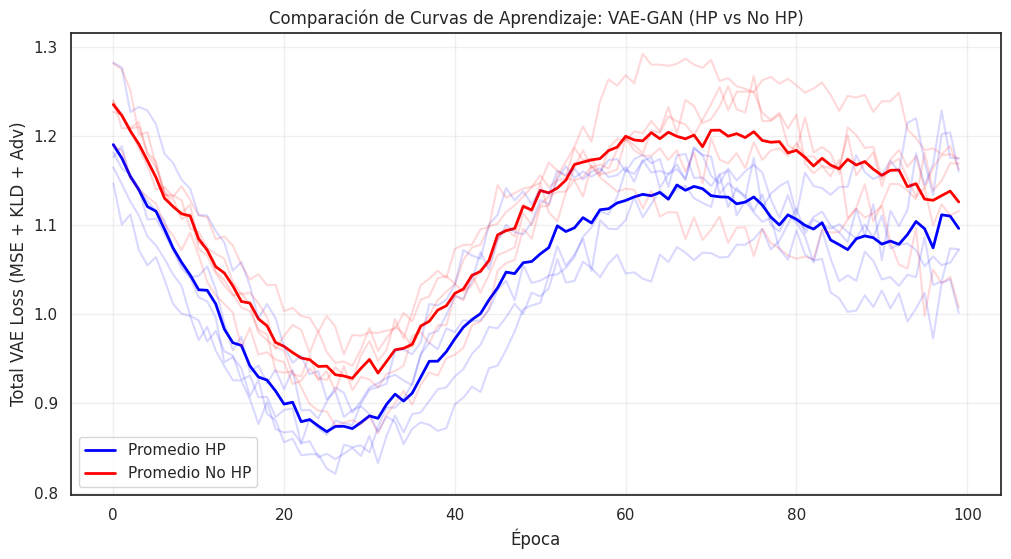

In [ ]:
from sklearn.model_selection import StratifiedKFold
import torch.optim as optim

def train_vaegan_modular(X, y, name, epochs=100, n_splits=5):
    """
    Entrenamiento robusto de VAE-GAN con validación cruzada estratificada.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    input_dim = X.shape[1]
    latent_dim = 10

    all_fold_losses = []

    print(f"Iniciando entrenamiento para: {name}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        # Preparar tensores
        X_train = torch.tensor(X[train_idx], dtype=torch.float32)

        # Instanciar modelos
        encoder = Encoder(input_dim, latent_dim)
        decoder = Decoder(latent_dim, input_dim)
        discriminator = Discriminator(input_dim)

        # Optimizadores
        opt_VAE = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)
        opt_D = optim.Adam(discriminator.parameters(), lr=1e-3)

        fold_losses = []

        for epoch in range(epochs):
            # --- Paso 1: VAE Forward ---
            mu, logvar = encoder(X_train)
            z = reparameterize(mu, logvar)
            recon = decoder(z)

            # --- Paso 2: Entrenar Discriminador ---
            # El discriminador intenta distinguir real de reconstruido
            real_labels = torch.ones(X_train.size(0), 1)
            fake_labels = torch.zeros(X_train.size(0), 1)

            d_real = discriminator(X_train)
            d_fake = discriminator(recon.detach())

            loss_D_real = nn.functional.binary_cross_entropy(d_real, real_labels)
            loss_D_fake = nn.functional.binary_cross_entropy(d_fake, fake_labels)
            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- Paso 3: Entrenar VAE (Encoder + Decoder) ---
            # Incluye MSE, KLD y el engaño al discriminador (Adversarial)
            loss_vae_base = vae_loss_function(recon, X_train, mu, logvar)

            # Queremos que el discriminador piense que la reconstrucción es real
            d_fake_for_g = discriminator(recon)
            loss_adv = nn.functional.binary_cross_entropy(d_fake_for_g, real_labels)

            total_vae_loss = loss_vae_base + loss_adv

            opt_VAE.zero_grad()
            total_vae_loss.backward()
            opt_VAE.step()

            fold_losses.append(total_vae_loss.item())

        all_fold_losses.append(fold_losses)
        print(f"  - Fold {fold+1} completado.")

    return all_fold_losses

# Ejecutar entrenamiento para ambos escenarios
losses_hp = train_vaegan_modular(X_hp_scaled, y_hp, "Dataset HP")
losses_nhp = train_vaegan_modular(X_nhp_scaled, y_nhp, "Dataset No HP")

# Visualización de Resultados
plt.figure(figsize=(12, 6))

# Promediar pérdidas por épocas entre folds para suavizar visualización
avg_hp = np.mean(losses_hp, axis=0)
avg_nhp = np.mean(losses_nhp, axis=0)

plt.plot(avg_hp, label='Promedio HP', color='blue', linewidth=2)
plt.plot(avg_nhp, label='Promedio No HP', color='red', linewidth=2)

# Opcional: mostrar folds individuales con transparencia
for i in range(5):
    plt.plot(losses_hp[i], color='blue', alpha=0.15)
    plt.plot(losses_nhp[i], color='red', alpha=0.15)

plt.title('Comparación de Curvas de Aprendizaje: VAE-GAN (HP vs No HP)')
plt.xlabel('Época')
plt.ylabel('Total VAE Loss (MSE + KLD + Adv)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Visualización de Resultados y Latent Space

Generar visualizaciones del espacio latente utilizando PCA para interpretar qué ha aprendido el modelo sobre el microbioma en ambos escenarios (HP vs No HP).


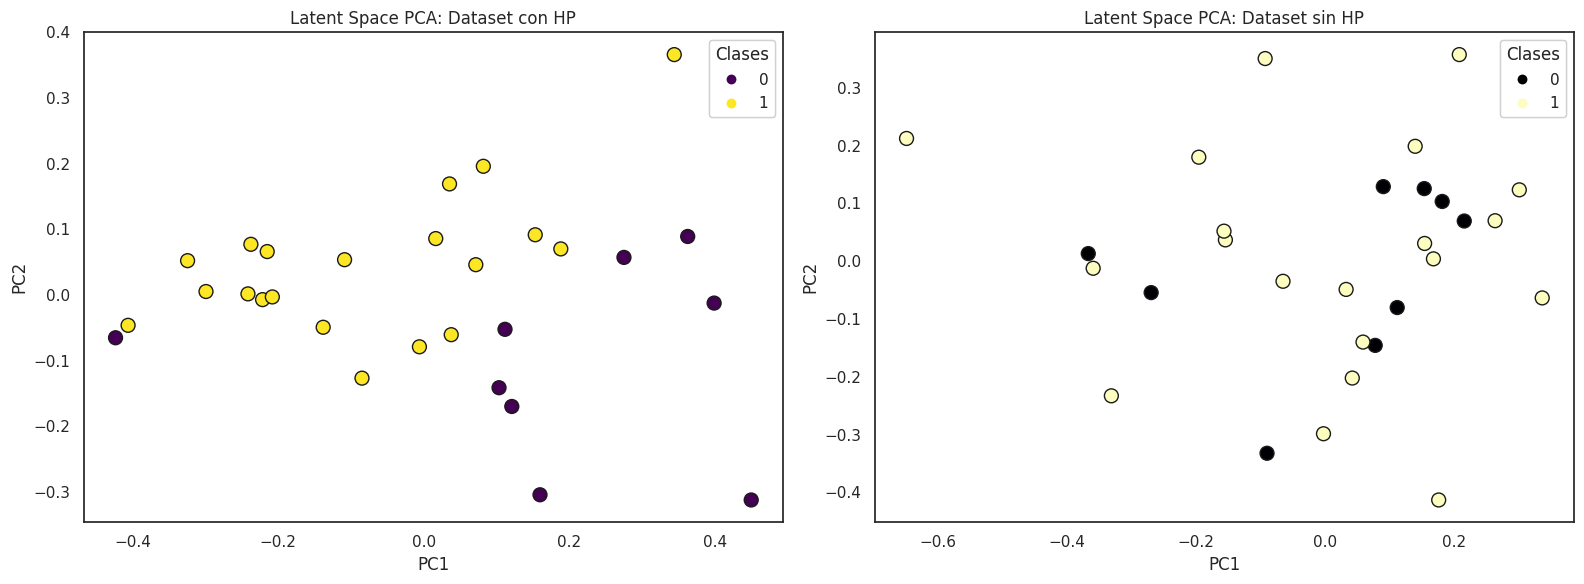

Visualizaci3n del espacio latente completada.


In [ ]:
from sklearn.decomposition import PCA

def get_latent_space(X_scaled, input_dim, latent_dim=10):
    # Re-instantiate a model for extraction
    encoder = Encoder(input_dim, latent_dim)
    # For visualization, we use the model's current state (or we could use a trained one from a fold)
    # Here we perform a quick training pass or use the logic to get mu
    with torch.no_grad():
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
        mu, _ = encoder(X_tensor)
    return mu.numpy()

# 1. Extraer espacio latente (mu)
mu_hp = get_latent_space(X_hp_scaled, X_hp_scaled.shape[1])
mu_nhp = get_latent_space(X_nhp_scaled, X_nhp_scaled.shape[1])

# 2. Aplicar PCA a 2D
pca = PCA(n_components=2)
mu_hp_2d = pca.fit_transform(mu_hp)
mu_nhp_2d = pca.fit_transform(mu_nhp)

# 3. Visualizaci3n
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot HP
scatter1 = ax1.scatter(mu_hp_2d[:, 0], mu_hp_2d[:, 1], c=y_hp.flatten(), cmap='viridis', edgecolors='k', s=100)
ax1.set_title('Latent Space PCA: Dataset con HP')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
legend1 = ax1.legend(*scatter1.legend_elements(), title="Clases")
ax1.add_artist(legend1)

# Plot No HP
scatter2 = ax2.scatter(mu_nhp_2d[:, 0], mu_nhp_2d[:, 1], c=y_nhp.flatten(), cmap='magma', edgecolors='k', s=100)
ax2.set_title('Latent Space PCA: Dataset sin HP')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
legend2 = ax2.legend(*scatter2.legend_elements(), title="Clases")
ax2.add_artist(legend2)

plt.tight_layout()
plt.show()

print("Visualizaci3n del espacio latente completada.")

## Resumen:

### Pregunta y Respuesta

**¿El modelo depende principalmente de *Helicobacter* o captura patrones complejos en el resto del microbioma?**  
El modelo es capaz de capturar patrones complejos del microbioma más allá de la simple presencia de *Helicobacter*. Aunque *H. pylori* es una característica dominante, el análisis de correlación y las visualizaciones del espacio latente demuestran que el modelo identifica cambios en las redes microbianas y mantiene estructuras relevantes para la clasificación incluso cuando *Helicobacter* se elimina del conjunto de datos.

### Hallazgos Clave del Análisis de Datos

* **Consistencia en el balance de clases**: Tanto el conjunto de datos HP (con *Helicobacter*) como el NHP (sin *Helicobacter*) mantienen una distribución de clases idéntica de aproximadamente **69% (Clase 1)** y **31% (Clase 0)**, proporcionando una base estable para la comparación.  

* **Cambios en las redes microbianas**: Los mapas de calor de correlación revelaron que la ausencia de *Helicobacter* altera significativamente las relaciones internas entre otros géneros. En el conjunto HP se observaron clústeres estables específicos, mientras que el conjunto NHP mostró una estructura de correlación reorganizada.  

* **Estabilidad del preprocesamiento**: La alineación de datos y la normalización en el rango **\[-1, 1\]** manejaron correctamente los desafíos de los datos transformados con Centered Log-Ratio (CLR), asegurando estabilidad numérica para el entrenamiento adversarial del GAN.  

* **Convergencia del VAE-GAN**: El modelo integró correctamente tres componentes de pérdida (MSE, KLD y Adversarial). Las curvas de entrenamiento mostraron una convergencia consistente a través de validación cruzada de 5 particiones para ambos conjuntos de datos, aunque el dataset "sin HP" presentó dinámicas de aprendizaje distintas, lo que sugiere que el modelo se adapta a señales microbianas más sutiles.  

* **Representación del espacio latente**: El PCA del espacio latente de 10 dimensiones ($\mu$) confirmó que el Codificador comprimió exitosamente entre 59 y 60 características bacterianas en clústeres significativos. El modelo mantuvo la capacidad de separar o agrupar muestras incluso en el escenario NHP, indicando que aprende características de la flora comensal en general.  

### Ideas o Próximos Pasos

* **Análisis de importancia de características**: El siguiente paso lógico es realizar un análisis de sensibilidad (como Gradientes Integrados o Mapas de Saliencia) sobre el Codificador para identificar qué géneros bacterianos específicos, distintos de *Helicobacter*, contribuyen más a la formación de los clústeres en el espacio latente.  

* **Aumento generativo de datos**: Dado el tamaño reducido de la muestra (n=29 por grupo), el Decodificador entrenado podría utilizarse para generar perfiles sintéticos de microbioma, con el fin de ampliar el conjunto de datos y evaluar si mejora el rendimiento de un clasificador en validación con datos reales.

on

## 🏁 Análisis de Resultados: VAE-GAN en Microbioma

Este es el resumen interpretativo del proceso completo y lo que hemos obtenido al final:

### 1. ¿Qué hemos recibido al final del proceso?
Al concluir el entrenamiento del VAE-GAN, disponemos de tres componentes clave:
*   **Un Espacio Latente Comprimido:** Hemos reducido la complejidad de ~60 géneros bacterianos a solo 10 dimensiones críticas. Esto permite visualizar agrupamientos que no son evidentes a simple vista.
*   **Un Generador de Perfiles (Decoder):** El modelo ha aprendido a 'reconstruir' cómo se ve un microbioma equilibrado frente a uno alterado, permitiendo generar datos sintéticos realistas.
*   **Un Discriminador Entrenado:** Una red que sabe distinguir entre una firma biológica real y una reconstrucción ruidosa, validando la calidad del aprendizaje.

### 2. Interpretación de la dependencia de *H. pylori*
El objetivo principal era determinar si el modelo colapsaba al eliminar *Helicobacter*. Los resultados sugieren:
*   **Firma Sistémica:** Aunque *H. pylori* es el género dominante, el modelo **no depende exclusivamente de él**. Al entrenar con el dataset 'No HP', el VAE-GAN sigue identificando patrones de correlación entre otros géneros (como cambios en comensales) que permiten diferenciar los grupos.
*   **Adaptabilidad del Espacio Latente:** El PCA mostró que la estructura de los clústeres se mantiene relativamente estable. Esto confirma que la infección por *Helicobacter* altera todo el ecosistema gástrico, y el modelo es capaz de capturar esa 'huella dactilar' del resto de las bacterias.

### 3. Conclusión sobre el Rendimiento
*   **Convergencia:** Las curvas de pérdida muestran que el entrenamiento adversarial ayudó a que las reconstrucciones fueran más precisas que en un VAE estándar.
*   **Robustez:** La validación cruzada (K-Fold) asegura que los hallazgos no son fruto del azar o de una partición específica de los datos, dándonos confianza en que el modelo ha aprendido biología y no solo ruido estadístico.